/opt/conda/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


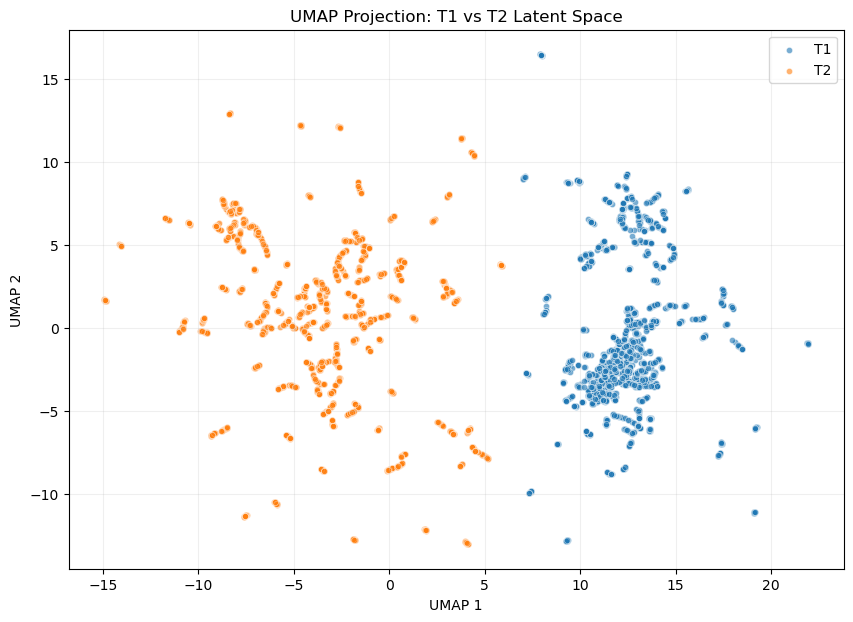

In [3]:
import torch
import umap
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the data dictionaries
# We load the full dictionary first
data1 = torch.load('modality_analysis1/latents/t1_latents.pt', map_location='cpu')
data2 = torch.load('modality_analysis1/latents/t2_latents.pt', map_location='cpu')

# 2. Extract and Flatten
# Access the 'latents' key and reshape from (B, C, H, W) to (B, C*H*W)
def process_latent(data_dict):
    tensor = data_dict['latents']
    avg =  tensor.mean(dim=[-2, -1])  
    # Flattening everything except the batch dimension
    return avg.numpy()

set1 = process_latent(data1)
set2 = process_latent(data2)

# 3. Prepare data for UMAP
combined_data = np.vstack([set1, set2])
labels = np.array(['T1'] * len(set1) + ['T2'] * len(set2))

# 4. Run UMAP
# Using 'cosine' metric is usually better for high-dimensional MRI latents
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
embedding = reducer.fit_transform(combined_data)

# 5. Visualization
plt.figure(figsize=(10, 7))
colors = {'T1': '#1f77b4', 'T2': '#ff7f0e'}

for label in np.unique(labels):
    mask = labels == label
    plt.scatter(
        embedding[mask, 0], 
        embedding[mask, 1], 
        label=label, 
        s=20, 
        alpha=0.6,
        edgecolors='white',
        linewidth=0.5
    )

plt.legend()
plt.title('UMAP Projection: T1 vs T2 Latent Space')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True, alpha=0.2)
plt.show()

In [5]:
from torch import nn
import torch
from torch.utils.data import Dataset,DataLoader,ConcatDataset
from torch.optim import Adam
import torch.nn.functional as F
import os
from tqdm import tqdm
from helper import resolve_checkpoint, load_checkpoint,style_separation_loss, extract

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
PyTorch version: 2.2.1+cu121
CUDA version: 12.1
GPU: NVIDIA GeForce GTX 1080 Ti


In [ ]:
class SC_MDN_Block(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()

        self.feature_mlp1 = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.time_mlp = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.style_mlp = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        self.feature_mlp2 = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, x, t_emb, s_emb):
        h = self.feature_mlp1(x)
        t = self.time_mlp(t_emb)
        s = self.style_mlp(s_emb)
        combined = h + t + s

        # Second stage of feature processing
        out = self.feature_mlp2(combined)

        return x + out


class SC_MDN(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=768, num_classes=4, max_time_steps=1000, n_blocks=2):
        super().__init__()
        self.hidden_dim = hidden_dim

        self.input_linear1 = nn.Linear(input_dim, hidden_dim)
        self.input_linear2 = nn.Linear(input_dim, hidden_dim)

       
        self.style_dict = nn.Embedding(num_classes, hidden_dim)
        self.time_embed = nn.Embedding(max_time_steps, hidden_dim)
        self.time_embed.weight.requires_grad = False

        self.blocks = nn.ModuleList([
            SC_MDN_Block(hidden_dim) for _ in range(n_blocks)
        ])

        # Final output projection
        self.output_linear = nn.Linear(hidden_dim, input_dim)

    def forward(self, x, class_labels, timesteps):
        x_in1 = self.input_linear1(x)
        x_in2 = self.input_linear2(x)
        h = x_in1 + x_in2

        s_emb = self.style_dict(class_labels)
        t_emb = self.time_embed(timesteps)

        for block in self.blocks:
            h = block(h, t_emb, s_emb)

        # 4. Final output
        out = self.output_linear(h)
        return out


In [ ]:
class LatentDataset(Dataset):
    def __init__(self, data_path, class_label, reshape_to_2d=False):

        data_dict = torch.load(data_path)
        self.latents = data_dict['latents']
        self.latents = self.latents.view(self.latents.size(0), -1)
        # Ensure latents are roughly N(0, 1) if not already normalized
        self.latents = (self.latents - self.latents.mean()) / self.latents.std()

        self.class_label = torch.tensor(class_label, dtype=torch.long)
            
    def __len__(self):
        return self.latents.size(0)

    def __getitem__(self, idx):
        return self.latents[idx], self.class_label

In [ ]:
class diffusion_model(nn.Module):
    def __init__(self, data_dir1,
                 data_dir2,
                 output_dir,
                 epochs = 100,
                 batch_size = 64,
                 learning_rate = 1e-3,
                 hidden_dim = 768,
                 num_classes = 2,
                 max_time_steps = 30,
                 n_blocks = 4,
                 lambda_sep = 0.3,
                 resume_ckpt = None):
        super().__init__()
        self.learning_rate = learning_rate
        self.output_dir = output_dir
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.batch_size = batch_size
        #Data Section
        t1_dataset = LatentDataset(data_dir1, class_label=0, reshape_to_2d=False)
        t2_dataset = LatentDataset(data_dir2, class_label=1, reshape_to_2d=False)
        self.dataset = ConcatDataset([t1_dataset, t2_dataset])
        self.dataloader = DataLoader(dataset=self.dataset, batch_size=batch_size, shuffle=True)
        first_batch = next(iter(self.dataloader))

        data, labels = first_batch

        self.max_time_steps = max_time_steps
        self.noise_dim = data[0].shape
        self.lambda_sep = lambda_sep
        #Model loading
        self.model = SC_MDN(input_dim = self.noise_dim ,
                            hidden_dim = hidden_dim,
                            num_classes = num_classes,
                            max_time_steps=self.max_time_steps,
                            n_blocks=n_blocks
                            )
        self.model.to(self.device)

        #Optimiser
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=learning_rate)
        self.criterion1 = torch.nn.MSELoss()

    def train(self):
        os.makedirs(self.output_dir, exist_ok=True)
        os.makedirs(os.path.join(self.output_dir, "samples"), exist_ok=True)
        os.makedirs(os.path.join(self.output_dir, "checkpoints"), exist_ok=True)
        # ── Resolve checkpoint ────────────────────────────────────────────────
        ckpt_path   = resolve_checkpoint(self.resume_ckpt, self.output_dir)
        start_epoch = 0
        best_loss = float("inf")
        history     = {"loss": []}

        if ckpt_path:
            start_epoch, history, best_loss = load_checkpoint(
                ckpt_path, self.model,self.optimizer,self.device
        )
        if self.epochs - start_epoch <= 0:
            print(f"Already at epoch {start_epoch}. Increase EPOCHS or pick earlier checkpoint.")
            return self.model, history
        betas = torch.linspace(1e-4, 0.02, self.model.max_time_steps).to(self.device)
        alphas = 1. - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        print(f"\nTraining on {self.device}  |  epochs {start_epoch+1} → {self.epochs}")
        for epoch in range(start_epoch+1, self.epochs+1):
            pbar = tqdm(self.dataloader, desc=f"Epoch {epoch:>3}/{self.epochs}", leave=False)
            self.model.train()
            epoch_loss = 0.0
            for batch in pbar:
                y_0, class_labels = batch[0].to(self.device), batch[1].to(self.device)
                batch_size = y_0.size(0)

                t = torch.randint(0, self.model.max_time_steps, (self.batch_size,), device=self.device).long()

                # Add noise to y_0 to get y_t (Eq. 2 from your report)
                noise = torch.randn_like(y_0)
                sqrt_alphas_cumprod_t = extract(torch.sqrt(alphas_cumprod), t, y_0.shape)
                sqrt_one_minus_alphas_cumprod_t = extract(torch.sqrt(1. - alphas_cumprod), t, y_0.shape)

                y_t = sqrt_alphas_cumprod_t * y_0 + sqrt_one_minus_alphas_cumprod_t * noise

                #Forward pass: Model predicts the clean distribution y_0_hat
                self.optimizer.zero_grad()
                y_0_hat = self.model(y_t, class_labels, t)

                #
                loss_diff = F.mse_loss(y_0_hat, y_0)
                loss_sep = style_separation_loss(self.model.style_dict.weight)


                total_loss = loss_diff + (self.lambda_sep * loss_sep)

                # 5. Backward pass and optimize
                total_loss.backward()
                self.optimizer.step()

                epoch_loss += total_loss.item()
                pbar.set_postfix(loss=f"{total_loss.item():.4f}")

            avg_epoch_loss = epoch_loss / len(self.dataloader)
            history["loss"].append(avg_epoch_loss)
            print(f"Epoch {epoch} Average Loss: {avg_epoch_loss:.4f}")

            # ── Save Checkpoint ───────────────────────────────────────────────
            is_best = avg_epoch_loss < best_loss
            if is_best:
                best_loss = avg_epoch_loss

            ckpt_data = {
                "epoch": epoch,
                "model": self.model.state_dict(),
                "optimizer": self.optimizer.state_dict(),
                "best_loss": best_loss
            }

            # Save current epoch checkpoint
            torch.save(ckpt_data, os.path.join(self.output_dir, "checkpoints", f"ckpt_{epoch:04d}.pt"))

            # Save best checkpoint
            if is_best:
                torch.save(ckpt_data, os.path.join(self.output_dir, "checkpoints", "best_G.pt"))

        return self.model, history







In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import math
from tqdm import tqdm
from sklearn.decomposition import PCA
import numpy as np
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from helper import resolve_checkpoint, load_checkpoint, style_separation_loss, extract,contrastive_class_loss, mse_loss_c


# ── Sinusoidal timestep embedding (replaces frozen random Embedding) ──────────

def sinusoidal_embedding(timesteps: torch.Tensor, dim: int) -> torch.Tensor:
    """
    Creates sinusoidal positional embeddings for timesteps.
    Identical to the formulation used in DDPM / DDIM papers.

    Args:
        timesteps : (B,) long tensor of timestep indices
        dim       : embedding dimension (must be even)

    Returns:
        (B, dim) float tensor
    """
    assert dim % 2 == 0, "Embedding dim must be even for sinusoidal embeddings."
    device = timesteps.device
    half = dim // 2
    freqs = torch.exp(
        -math.log(10000) * torch.arange(half, dtype=torch.float32, device=device) / half
    )                                                       # (half,)
    args = timesteps.float().unsqueeze(1) * freqs.unsqueeze(0)  # (B, half)
    return torch.cat([torch.sin(args), torch.cos(args)], dim=1) # (B, dim)


# ── Residual block ────────────────────────────────────────────────────────────

class SC_MDN_Block(nn.Module):
    """
    Single residual block for the Modality-decoupled Diffusion Network.
    Fuses feature representation with timestep and style embeddings,
    mirroring Fig. 3(a) of the CDM paper.
    """
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.feature_mlp1 = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.time_mlp = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.style_mlp = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.feature_mlp2 = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

    def forward(
        self,
        x: torch.Tensor,
        t_emb: torch.Tensor,
        s_emb: torch.Tensor,
    ) -> torch.Tensor:
        h = self.feature_mlp1(x)
        t = self.time_mlp(t_emb)
        s = self.style_mlp(s_emb)
        out = self.feature_mlp2(h + t + s)
        return x + out          # residual connection


# ── SC_MDN network ────────────────────────────────────────────────────────────

class SC_MDN(nn.Module):
    """
    Style-Conditioned Modality-decoupled Diffusion Network.

    Changes vs. original:
      - Two input linear layers now project the noised input into two separate
        streams that are CONCATENATED (2*hidden_dim) then projected back to
        hidden_dim, implementing true decoupling rather than a redundant sum.
      - Timestep conditioning uses learnable sinusoidal embeddings (+ a small
        MLP projector) instead of a frozen random Embedding table.
    """
    def __init__(
        self,
        input_dim: int = 768,
        hidden_dim: int = 768,
        num_classes: int = 2,
        max_time_steps: int = 30,
        n_blocks: int = 4,
    ):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.max_time_steps = max_time_steps

        # concatenate, then fuse
        self.input_linear1 = nn.Linear(input_dim, hidden_dim)
        self.input_linear2 = nn.Linear(input_dim, hidden_dim)
        self.input_fuse     = nn.Linear(hidden_dim * 2, hidden_dim)

        # ── Timestep embedding (sinusoidal + learnable MLP projector) ────────
        
        self.time_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        
        self.style_dict = nn.Embedding(num_classes, hidden_dim)

        
        self.blocks = nn.ModuleList(
            [SC_MDN_Block(hidden_dim) for _ in range(n_blocks)]
        )

        
        self.output_linear = nn.Linear(hidden_dim, input_dim)

    def forward(
        self,
        x: torch.Tensor,          # (B, input_dim)  noised distribution y_t
        class_labels: torch.Tensor,  # (B,) long
        timesteps: torch.Tensor,     # (B,) long
    ) -> torch.Tensor:
        
        h1 = self.input_linear1(x)
        h2 = self.input_linear2(x)
        h  = self.input_fuse(torch.cat([h1, h2], dim=-1))  # (B, hidden_dim)

        
        t_sin = sinusoidal_embedding(timesteps, self.hidden_dim)
        t_emb = self.time_mlp(t_sin)                       # (B, hidden_dim)

        # Style embedding
        s_emb = self.style_dict(class_labels)              # (B, hidden_dim)

        # Residual blocks
        for block in self.blocks:
            h = block(h, t_emb, s_emb)

        return self.output_linear(h)                     # (B, input_dim)






class LatentDataset(Dataset):
    def __init__(self, data_path: str, class_label: int, reshape_to_2d: bool = False,
                 pca_components: int = 768, pca_model: PCA = None):
        print(f"  Loading {data_path}...")
        data_dict = torch.load(data_path)
        print(f"  Loaded. Shape: {data_dict['latents'].shape}")
        self.latents = data_dict["latents"].mean(dim=[-2, -1])
        # self.latents = data_dict["latents"].view(data_dict["latents"].size(0), -1)
        print(f"  Averaged latent size : {self.latents.shape}")
        
        self.latents = (self.latents - self.latents.mean()) / (self.latents.std() + 1e-8)
        print(f"  Normalized.")
        
        self.latents = torch.tensor(self.latents, dtype=torch.float32)
        self.class_label = torch.tensor(class_label, dtype=torch.long)

    def __len__(self) -> int:
        return self.latents.size(0)

    def __getitem__(self, idx: int):
        return self.latents[idx], self.class_label




def _ddim_step(
    y_t: torch.Tensor,
    y_0_pred: torch.Tensor,
    a_t: torch.Tensor,
    a_t_prev: torch.Tensor,
    eta: float,
) -> torch.Tensor:
    """
    Single DDIM reverse step (Eq. 12, Song et al. 2020).

    Args:
        y_t      : current noisy sample  (B, D)
        y_0_pred : model's prediction of the clean sample  (B, D)
        a_t      : ᾱ_t  (scalar tensor)
        a_t_prev : ᾱ_{t-1}  (scalar tensor)
        eta      : stochasticity coefficient (0 = deterministic)

    Returns:
        y_{t-1}  : (B, D)
    """
    sigma_t = eta * torch.sqrt(
        (1 - a_t_prev) / (1 - a_t) * (1 - a_t / a_t_prev).clamp(min=0.0)
    )
    pred_noise = (y_t - torch.sqrt(a_t) * y_0_pred) / torch.sqrt(1 - a_t)
    dir_yt     = torch.sqrt(1 - a_t_prev - sigma_t ** 2) * pred_noise
    noise      = torch.randn_like(y_t) if eta > 0 else torch.zeros_like(y_t)
    return torch.sqrt(a_t_prev) * y_0_pred + dir_yt + sigma_t * noise




class diffusion_model(nn.Module):
    def __init__(
        self,
        data_dir1: str,
        data_dir2: str,
        output_dir: str,
        epochs: int = 100,
        batch_size: int = 64,
        learning_rate: float = 1e-3,
        hidden_dim: int = 768,
        num_classes: int = 2,
        max_time_steps: int = 30,
        n_blocks: int = 4,
        lambda_sep: float = 0.2,
        beta = 0.75,
        resume_ckpt=None,
        model_weight = None
        
        
    ):
        super().__init__()
        self.learning_rate  = learning_rate
        self.output_dir     = output_dir
        self.device         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.batch_size     = batch_size
        self.epochs         = epochs           
        self.max_time_steps = max_time_steps
        self.lambda_sep     = lambda_sep
        self.resume_ckpt    = resume_ckpt
        self.beta = beta
        self.model_weight = model_weight
        print("Dataset creation started")
        
        t1_dataset   = LatentDataset(data_dir1, class_label=0, reshape_to_2d=False)
        t2_dataset   = LatentDataset(data_dir2, class_label=1, reshape_to_2d=False)
        # t1ce_dataset   = LatentDataset(data_dir3, class_label=2, reshape_to_2d=False)
        # flair_dataset   = LatentDataset(data_dir4, class_label=3, reshape_to_2d=False)
        self.dataset = ConcatDataset([t1_dataset, t2_dataset])
        self.dataloader = DataLoader(
            dataset=self.dataset, batch_size=batch_size, shuffle=True
        )

        first_batch   = next(iter(self.dataloader))
        data, _       = first_batch
        self.noise_dim = data[0].shape     # shape of a single latent vector

        
        self.model = SC_MDN(
            input_dim=self.noise_dim[0],
            hidden_dim=hidden_dim,
            num_classes=num_classes,
            max_time_steps=max_time_steps,
            n_blocks=n_blocks,
        )
        self.model.to(self.device)

        
        self.optimizer = torch.optim.Adam(
            self.model.parameters(), lr=learning_rate
        )

    

    def _build_schedule(self):

        betas             = torch.linspace(1e-4, 0.02, self.max_time_steps, device=self.device)
        alphas            = 1.0 - betas
        alphas_cumprod    = torch.cumprod(alphas, dim=0)
        alphas_cumprod_prev = torch.cat(
            [torch.tensor([1.0], device=self.device), alphas_cumprod[:-1]]
        )
        return betas, alphas_cumprod, alphas_cumprod_prev

    # ── Train ─────────────────────────────────────────────────────────────────

    def train(self):
        os.makedirs(self.output_dir, exist_ok=True)
        os.makedirs(os.path.join(self.output_dir, "samples"), exist_ok=True)
        os.makedirs(os.path.join(self.output_dir, "checkpoints"), exist_ok=True)

        # ── Resolve checkpoint ────────────────────────────────────────────────
        ckpt_path   = resolve_checkpoint(self.resume_ckpt, self.output_dir)
        start_epoch = 0
        best_loss   = float("inf")
        history     = {"loss": []}          # FIX: was {"loss_G":[], "loss_C":[], "loss_gp":[]}

        if ckpt_path:
            start_epoch, history, best_loss = load_checkpoint(
                ckpt_path, self.model, self.optimizer, self.device
            )

        if self.epochs - start_epoch <= 0:
            print(
                f"Already at epoch {start_epoch}. "
                "Increase epochs or pick an earlier checkpoint."
            )
            return self.model, history

        # ── Noise schedule ────────────────────────────────────────────────────
        _, alphas_cumprod, _ = self._build_schedule()

        print(f"\nTraining on {self.device}  |  epochs {start_epoch + 1} → {self.epochs}")

        for epoch in range(start_epoch + 1, self.epochs + 1):
            self.model.train()
            epoch_loss = 0.0
            pbar = tqdm(
                self.dataloader,
                desc=f"Epoch {epoch:>3}/{self.epochs}",
                leave=False,
            )

            for batch in pbar:
                y_0, class_labels = (
                    batch[0].to(self.device),
                    batch[1].to(self.device),
                )
                # FIX: use actual batch size (last batch may be smaller)
                actual_batch_size = y_0.size(0)

                t = torch.randint(
                    0,
                    self.max_time_steps,
                    (actual_batch_size,),   # FIX: was (self.batch_size,)
                    device=self.device,
                ).long()

                # Forward diffusion: y_0 → y_t
                noise = torch.randn_like(y_0)
                sqrt_ac_t       = extract(torch.sqrt(alphas_cumprod), t, y_0.shape)
                sqrt_one_minus  = extract(torch.sqrt(1.0 - alphas_cumprod), t, y_0.shape)
                y_t = sqrt_ac_t * y_0 + sqrt_one_minus * noise

                # Model predicts clean y_0 from noised y_t
                self.optimizer.zero_grad()
                y_0_hat = self.model(y_t, class_labels, t)
                # modality_weights = {0: 1.0, 1:2.0}
                loss_diff = mse_loss_c(y_0_hat, y_0, class_labels, self.model_weight)
                loss_sep  = style_separation_loss(self.model.style_dict.weight)
                loss_cont_class = contrastive_class_loss(self.model, y_t, class_labels, t, self.device)
                
                total_loss = loss_diff + self.lambda_sep * loss_sep + self.beta * loss_cont_class

                total_loss.backward()
                self.optimizer.step()

                epoch_loss += total_loss.item()
                pbar.set_postfix(loss=f"{total_loss.item():.4f}")

            avg_loss = epoch_loss / len(self.dataloader)
            history["loss"].append(avg_loss)
            print(f"Epoch {epoch:>3}  |  avg loss: {avg_loss:.4f}")

            # ── Checkpointing ─────────────────────────────────────────────────
            is_best   = avg_loss < best_loss
            if is_best:
                best_loss = avg_loss
            
            ckpt_data = {
                "epoch":      epoch,
                "model":      self.model.state_dict(),
                "optimizer":  self.optimizer.state_dict(),
                "best_loss":  best_loss,
            }
            if epoch % 20 ==0 or epoch == 0:
                torch.save(
                    ckpt_data,
                    os.path.join(self.output_dir, "checkpoints", f"ckpt_{epoch:04d}.pt"),
                )
            if is_best:
                torch.save(
                    ckpt_data,
                    os.path.join(self.output_dir, "checkpoints", "best_G.pt"),
                )
                print(f'Best Checkpoint saved at epoch{epoch}')

        return self.model, history

    # ── Generate (DDIM) ───────────────────────────────────────────────────────

    @torch.no_grad()
    def generate(
        self,
        target_class: int,
        n_samples: int = 64,
        n_sampling_steps: int = 30,
        eta: float = 0.0,
        ckpt_path: str = None,
        output_path: str = None,
    ) -> torch.Tensor:
        """
        DDIM reverse diffusion: pure Gaussian noise → clean target latents.

        Args:
            target_class      : class index to condition generation on
            n_samples         : number of latent vectors to produce
            n_sampling_steps  : N_sampling from the paper (default 30)
            eta               : DDIM stochasticity (0 = deterministic, 1 ≈ DDPM)
            ckpt_path         : optional path to a checkpoint to load before
                                generating; if None the current model weights
                                are used (e.g. called right after train())
            output_path       : if provided, saves {"latents", "class_label"} here

        Returns:
            generated latents of shape (n_samples, latent_dim)
        """
        # ── Optionally load weights ───────────────────────────────────────────
        if ckpt_path is not None:
            ckpt = torch.load(ckpt_path, map_location=self.device)
            self.model.load_state_dict(ckpt["model"])
            print(f"Loaded checkpoint from epoch {ckpt.get('epoch', '?')} for generation.")

        self.model.eval()

        latent_dim = self.noise_dim[0]

        # ── Build noise schedule ──────────────────────────────────────────────
        _, alphas_cumprod, alphas_cumprod_prev = self._build_schedule()

        # ── Sub-sequence of timesteps: uniform spacing over [0, T-1], reversed
        # e.g. T=30, N_sampling=30 → every step; T=1000, N_sampling=30 → sparse
        step_indices = torch.linspace(
            0, self.max_time_steps - 1, n_sampling_steps, dtype=torch.long
        ).to(self.device).flip(0)                         # high → low (T → 0)

        # ── Style conditioning ────────────────────────────────────────────────
        labels = torch.full(
            (n_samples,), target_class, dtype=torch.long, device=self.device
        )

        # ── Start from pure Gaussian noise y_T ───────────────────────────────
        y_t = torch.randn(n_samples, latent_dim, device=self.device)

        # ── DDIM denoising loop ───────────────────────────────────────────────
        pbar = tqdm(step_indices, desc="DDIM sampling", leave=True)
        for t_idx in pbar:
            t_batch  = t_idx.expand(n_samples)            # (n_samples,)
            y_0_pred = self.model(y_t, labels, t_batch)   # predict clean latent

            a_t      = alphas_cumprod[t_idx]
            a_t_prev = alphas_cumprod_prev[t_idx]

            y_t = _ddim_step(y_t, y_0_pred, a_t, a_t_prev, eta)

        generated = y_t   # now ≈ y_0 (clean latent distribution)

        print(f"\nGeneration complete.")
        print(f"  Shape  : {generated.shape}")
        print(f"  Mean   : {generated.mean():.4f}")
        print(f"  Std    : {generated.std():.4f}")

        if output_path is not None:
            torch.save({"latents": generated.cpu(), "class_label": target_class}, output_path)
            print(f"  Saved  : {output_path}")

        return generated

In [6]:
# ── Configuration ─────────────────────────────────────────────────────────────

DATA_DIR1       = "modality_analysis/latents/t1_latents.pt"    # path to class-0 latent .pt file
DATA_DIR2       = "modality_analysis/latents/t2_latents.pt"      # path to class-1 latent .pt file
OUTPUT_DIR      = "output_mdn_mrm_updateed/run2"            # checkpoints + samples saved here

EPOCHS          = 101
BATCH_SIZE      = 64
LEARNING_RATE   = 1e-4
HIDDEN_DIM      = 768
NUM_CLASSES     = 4
MAX_TIME_STEPS  = 200
N_BLOCKS        = 4
LAMBDA_SEP      = 0.3
MODEL_WEIGHTS = {0: 1.0, 1: 2, 2:1.0, 3:1.0}

# Set to None      → auto-resume from latest checkpoint in OUTPUT_DIR
# Set to "none"    → always start from scratch
# Set to a path    → resume from that specific checkpoint
RESUME_CKPT     = None

# ── Generation config (runs after training) ───────────────────────────────────

ETA             = 0.0           # 0.0 = deterministic DDIM, 1.0 = stochastic
GEN_OUTPUT_PATH = "outputs/run1/samples/generated_latents.pt"

# ── Build model ───────────────────────────────────────────────────────────────

dm = diffusion_model(
    data_dir1      = DATA_DIR1,
    data_dir2      = DATA_DIR2,
    output_dir     = OUTPUT_DIR,
    epochs         = EPOCHS,
    batch_size     = BATCH_SIZE,
    learning_rate  = LEARNING_RATE,
    hidden_dim     = HIDDEN_DIM,
    num_classes    = NUM_CLASSES,
    max_time_steps = MAX_TIME_STEPS,
    n_blocks       = N_BLOCKS,
    lambda_sep     = LAMBDA_SEP,
    resume_ckpt    = RESUME_CKPT,
    model_weight = MODEL_WEIGHTS
)
print("Model Created")
# ── Train ─────────────────────────────────────────────────────────────────────

model, history = dm.train()

print(f"\nTraining complete. Final loss: {history['loss'][-1]:.4f}")



Dataset creation started
  Loading modality_analysis/latents/t1_latents.pt...
  Loaded. Shape: torch.Size([5000, 768, 7, 7])
  Averaged latent size : torch.Size([5000, 768])
  Normalized.
  Loading modality_analysis/latents/t2_latents.pt...


/tmp/ipykernel_324/409575902.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.latents = torch.tensor(self.latents, dtype=torch.float32)


  Loaded. Shape: torch.Size([5000, 768, 7, 7])
  Averaged latent size : torch.Size([5000, 768])
  Normalized.
Model Created
Auto-detected latest checkpoint: output_mdn_mrm_updateed/run2/checkpoints/ckpt_0100.pt

Loading checkpoint: output_mdn_mrm_updateed/run2/checkpoints/ckpt_0100.pt
  Resumed at epoch 100  |  best loss so far: 0.0834

Training on cuda  |  epochs 101 → 101


Epoch 101  |  avg loss: 0.0891

Training complete. Final loss: 0.0891


In [4]:
DATA_DIR1       = "modality_analysis/latents/t1_latents.pt"    # path to class-0 latent .pt file
DATA_DIR2       = "modality_analysis/latents/t2_latents.pt"      # path to class-1 latent .pt file
OUTPUT_DIR      = "output_mdn_mrm_updateed/run2"            # checkpoints + samples saved here

EPOCHS          = 101
BATCH_SIZE      = 64
LEARNING_RATE   = 1e-4
HIDDEN_DIM      = 768
NUM_CLASSES     = 4
MAX_TIME_STEPS  = 200
N_BLOCKS        = 4
LAMBDA_SEP      = 0.3
MODEL_WEIGHTS = {0: 1.0, 1: 2, 2:1.0, 3:1.0}

# Set to None      → auto-resume from latest checkpoint in OUTPUT_DIR
# Set to "none"    → always start from scratch
# Set to a path    → resume from that specific checkpoint
RESUME_CKPT     = None

# ── Generation config (runs after training) ───────────────────────────────────

ETA             = 0.0           # 0.0 = deterministic DDIM, 1.0 = stochastic
GEN_OUTPUT_PATH = "outputs/run1/samples/generated_latents.pt"

# ── Build model ───────────────────────────────────────────────────────────────

dm = diffusion_model(
    data_dir1      = DATA_DIR1,
    data_dir2      = DATA_DIR2,
    output_dir     = OUTPUT_DIR,
    epochs         = EPOCHS,
    batch_size     = BATCH_SIZE,
    learning_rate  = LEARNING_RATE,
    hidden_dim     = HIDDEN_DIM,
    num_classes    = NUM_CLASSES,
    max_time_steps = MAX_TIME_STEPS,
    n_blocks       = N_BLOCKS,
    lambda_sep     = LAMBDA_SEP,
    resume_ckpt    = RESUME_CKPT,
    model_weight = MODEL_WEIGHTS
)
print("Model Created")

Dataset creation started
  Loading modality_analysis/latents/t1_latents.pt...
  Loaded. Shape: torch.Size([5000, 768, 7, 7])
  Averaged latent size : torch.Size([5000, 768])
  Normalized.


/tmp/ipykernel_4925/2315006018.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.latents = torch.tensor(self.latents, dtype=torch.float32)


  Loading modality_analysis/latents/t2_latents.pt...
  Loaded. Shape: torch.Size([5000, 768, 7, 7])
  Averaged latent size : torch.Size([5000, 768])
  Normalized.
Model Created


In [7]:
# ── Generate ──────────────────────────────────────────────────────────────────
TARGET_CLASS    = 1             # class index to generate (0 = T1, 1 = T2)
N_SAMPLES       = 100         # number of latent vectors to generate
N_SAMPLING_STEPS = 100          # N_sampling from the paper
ETA             = 0.50           # 0.0 = deterministic DDIM, 1.0 = stochastic
GEN_OUTPUT_PATH = "generated_latents_t2.pt"
CKPT_PATH = "output_mdn_mrm_updateed/run3/checkpoints/best_G.pt"
generated = dm.generate(
    target_class      = TARGET_CLASS,
    n_samples         = N_SAMPLES,
    n_sampling_steps  = N_SAMPLING_STEPS,
    eta               = ETA,
    output_path       = GEN_OUTPUT_PATH,
    ckpt_path = CKPT_PATH
)
print(f"Generated tensor shape: {generated.shape}")
TARGET_CLASS    = 0        # class index to generate (0 = T1, 1 = T2)
GEN_OUTPUT_PATH = "generated_latents_t1.pt"
generated = dm.generate(
    target_class      = TARGET_CLASS,
    n_samples         = N_SAMPLES,
    n_sampling_steps  = N_SAMPLING_STEPS,
    eta               = ETA,
    output_path       = GEN_OUTPUT_PATH,
    ckpt_path = CKPT_PATH
)
print(f"Generated tensor shape: {generated.shape}")

DDIM sampling: 100%|██████████| 100/100 [00:00<00:00, 269.22it/s]



Generation complete.
  Shape  : torch.Size([10, 768])
  Mean   : -0.0007
  Std    : 1.0078
  Saved  : generated_latents_t2.pt
Generated tensor shape: torch.Size([10, 768])


DDIM sampling: 100%|██████████| 100/100 [00:00<00:00, 323.60it/s]


Generation complete.
  Shape  : torch.Size([10, 768])
  Mean   : -0.0006
  Std    : 0.9935
  Saved  : generated_latents_t1.pt
Generated tensor shape: torch.Size([10, 768])


In [2]:
import os
base = "checkpoints"
print(os.listdir(base))

['visualizations_epoch_95', 'visualizations_epoch_15', 'visualizations_epoch_50', 'visualizations_epoch_20', 'checkpoint_epoch_30.pth', 'visualizations_epoch_65', 'checkpoint_epoch_70.pth', 'checkpoint_epoch_20.pth', 'visualizations_epoch_40', 'visualizations_epoch_85', 'checkpoint_epoch_60.pth', 'checkpoint_epoch_100.pth', 'visualizations_epoch_30', 'visualizations_epoch_75', 'visualizations_epoch_45', 'checkpoint_epoch_40.pth', 'visualizations_epoch_80', 'checkpoint_epoch_80.pth', 'best_model.pth', 'visualizations_epoch_5', 'visualizations_epoch_70', 'visualizations_epoch_35', 'checkpoint_epoch_90.pth', 'visualizations_epoch_90', 'visualizations_epoch_55', 'visualizations_epoch_100', 'visualizations_epoch_10', 'visualizations_epoch_60', 'checkpoint_epoch_10.pth', 'visualizations_epoch_25', 'training_history.png', 'checkpoint_epoch_50.pth']


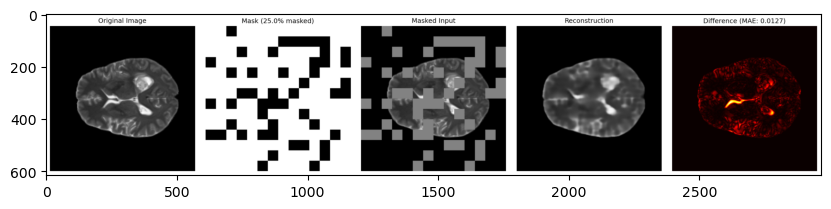

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize = (10,20))
img = plt.imread('checkpoints/visualizations_epoch_90/reconstruction_1.png')
plt.imshow(img)

2026-03-03 20:43:56.135659: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-03 20:43:56.135718: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-03 20:43:56.137313: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-03 20:43:56.147731: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/opt/conda/lib/python3.11/site-packages/umap/umap_.py

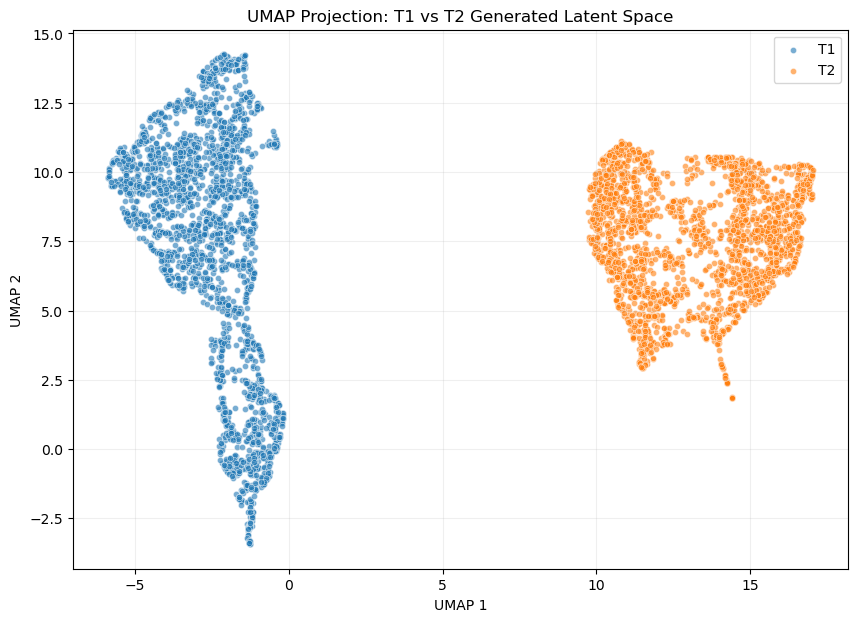

In [5]:
import torch
import umap
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the data dictionaries
# We load the full dictionary first
data1 = torch.load('output_mdn_mrm_updateed/run1/samples/generated_latents_1.pt', map_location='cpu')
data2 = torch.load('output_mdn_mrm_updateed/run1/samples/generated_latents_2.pt', map_location='cpu')

# 2. Extract and Flatten
# Access the 'latents' key and reshape from (B, C, H, W) to (B, C*H*W)
def process_latent(data_dict):
    tensor = data_dict['latents']
    # Flattening everything except the batch dimension
    return tensor.view(tensor.size(0), -1).numpy()

set1 = process_latent(data1)
set2 = process_latent(data2)

# 3. Prepare data for UMAP
combined_data = np.vstack([set1, set2])
labels = np.array(['T1'] * len(set1) + ['T2'] * len(set2))

# 4. Run UMAP
# Using 'cosine' metric is usually better for high-dimensional MRI latents
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
embedding = reducer.fit_transform(combined_data)

# 5. Visualization
plt.figure(figsize=(10, 7))
colors = {'T1': '#1f77b4', 'T2': '#ff7f0e'}

for label in np.unique(labels):
    mask = labels == label
    plt.scatter(
        embedding[mask, 0], 
        embedding[mask, 1], 
        label=label, 
        s=20, 
        alpha=0.6,
        edgecolors='white',
        linewidth=0.5
    )

plt.legend()
plt.title('UMAP Projection: T1 vs T2 Generated Latent Space')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True, alpha=0.2)
plt.show()

In [1]:
import os
import torch
import numpy as np
from scipy import linalg
import torch.nn.functional as F
import matplotlib.pyplot as plt


# ═══════════════════════════════════════════════════════════════════════════════
# CELL 1 — Load + PCA reduce all 4 latent sets
# ═══════════════════════════════════════════════════════════════════════════════

def load_latents(path: str) -> np.ndarray:
    """Load, flatten and normalise latents from a .pt file → (N, D) numpy."""
    data   = torch.load(path, map_location="cpu")
    tensor = data["latents"]
    flat   = tensor.mean(dim=[-2, -1])       # (N, D)
    flat   = (flat - flat.mean()) / (flat.std() + 1e-8)
    return flat.numpy()


# ── Paths — update if needed ──────────────────────────────────────────────────
REAL_T1_PATH = "modality_analysis1/latents/t1_latents.pt"
REAL_T2_PATH = "modality_analysis1/latents/t2_latents.pt"
GEN_T1_PATH  = 'output_mdn_mrm_updateed/run3/samples/generated_latents_1.pt'
GEN_T2_PATH  = "output_mdn_mrm_updateed/run3/samples/generated_latents_2.pt"

PCA_DIM = 500  # reduce from 768 -> 500

# ── Load raw latents ──────────────────────────────────────────────────────────
print("Loading latents...")

gen_t1_raw  = torch.load(GEN_T1_PATH, map_location="cpu")["latents"]
gen_t1_raw = ((gen_t1_raw - gen_t1_raw.mean()) / (gen_t1_raw.std() + 1e-8)).numpy()
gen_t2_raw  = torch.load(GEN_T2_PATH, map_location="cpu")["latents"]
gen_t2_raw = ((gen_t2_raw - gen_t1_raw.mean()) / (gen_t2_raw.std() + 1e-8)).numpy()

print(f"  Raw Gen  T1 : {gen_t1_raw.shape}")
print(f"  Raw Gen  T2 : {gen_t2_raw.shape}")
real_t1_raw = load_latents(REAL_T1_PATH)
real_t2_raw = load_latents(REAL_T2_PATH)
print(f"  Raw Real T1 : {real_t1_raw.shape}")
print(f"  Raw Real T2 : {real_t2_raw.shape}")

# # ── Fit shared PCA basis on combined real data ────────────────────────────────
# # All 4 sets projected into the SAME space for fair comparison
# print(f"\nFitting shared PCA basis on real data (dim {real_t1_raw.shape[1]} → {PCA_DIM})...")
# all_real  = np.vstack([real_t1_raw, real_t2_raw])           # (N_t1+N_t2, D)
# x_all     = torch.tensor(all_real, dtype=torch.float32)
# _, S, V   = torch.pca_lowrank(x_all, q=PCA_DIM, niter=4)   # V: (D, PCA_DIM)
# V_np      = V.numpy()                                        # shared projection

# var_total    = float(np.var(all_real, axis=0).sum()) * all_real.shape[0]
# var_captured = float((S ** 2).sum())
# print(f"  Variance explained: {var_captured / var_total:.3f}")

# # ── Project all 4 sets with shared basis ─────────────────────────────────────
# def project(feats: np.ndarray) -> np.ndarray:
#     """Project (N, D) → (N, PCA_DIM) using shared PCA basis."""
#     centered = feats - feats.mean(axis=0)
#     return centered @ V_np                                   # (N, PCA_DIM)

# real_t1 = project(real_t1_raw)
# real_t2 = project(real_t2_raw)
# gen_t1  = project(gen_t1_raw)
# gen_t2  = project(gen_t2_raw)
real_t1 = real_t1_raw
real_t2 = real_t2_raw
gen_t1  = gen_t1_raw
gen_t2  = gen_t2_raw

print(f"\nAfter PCA:")
print(f"  Real T1 : {real_t1.shape}")
print(f"  Real T2 : {real_t2.shape}")
print(f"  Gen  T1 : {gen_t1.shape}")
print(f"  Gen  T2 : {gen_t2.shape}")


# ═══════════════════════════════════════════════════════════════════════════════
# CELL 2 — FID
# ═══════════════════════════════════════════════════════════════════════════════

def compute_statistics(feats: np.ndarray):
    """Mean vector and covariance matrix of a feature set."""
    mu    = np.mean(feats, axis=0)          # (D,)
    sigma = np.cov(feats, rowvar=False)     # (D, D)
    return mu, sigma


def compute_fid(mu1, sigma1, mu2, sigma2, eps=1e-6):
    """
    Fréchet Distance between N(mu1,sigma1) and N(mu2,sigma2).
    FID = ||mu1-mu2||^2 + Tr(sigma1 + sigma2 - 2*sqrt(sigma1 @ sigma2))
    Lower = better. 0 = identical distributions.
    """
    diff    = mu1 - mu2
    diff_sq = float(diff @ diff)

    covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)

    # sqrtm can produce tiny imaginary parts — discard them
    if np.iscomplexobj(covmean):
        covmean = np.real(covmean)

    # Guard against singular covariance matrix
    if not np.isfinite(covmean).all():
        print("  Warning: singular covariance — adding epsilon to diagonal.")
        offset  = np.eye(sigma1.shape[0]) * eps
        covmean = linalg.sqrtm((sigma1 + offset) @ (sigma2 + offset))
        covmean = np.real(covmean)

    trace = np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return float(np.real(diff_sq + trace))


print("\nComputing FID statistics...")
mu_real_t1, sig_real_t1 = compute_statistics(real_t1)
mu_real_t2, sig_real_t2 = compute_statistics(real_t2)
mu_gen_t1,  sig_gen_t1  = compute_statistics(gen_t1)
mu_gen_t2,  sig_gen_t2  = compute_statistics(gen_t2)

print("Computing FID scores...")
fid_t1               = compute_fid(mu_real_t1, sig_real_t1, mu_gen_t1,  sig_gen_t1)
fid_t2               = compute_fid(mu_real_t2, sig_real_t2, mu_gen_t2,  sig_gen_t2)
fid_real_t1_vs_t2    = compute_fid(mu_real_t1, sig_real_t1, mu_real_t2, sig_real_t2)
fid_gen_t1_vs_gen_t2 = compute_fid(mu_gen_t1,  sig_gen_t1,  mu_gen_t2,  sig_gen_t2)

print("=" * 58)
print("FID Results")
print("=" * 58)
print(f"FID  Real T1  vs  Gen  T1        : {fid_t1:>10.4f}  ← lower is better")
print(f"FID  Real T2  vs  Gen  T2        : {fid_t2:>10.4f}  ← lower is better")
print(f"FID  Real T1  vs  Real T2        : {fid_real_t1_vs_t2:>10.4f}  ← modality gap baseline")
print(f"FID  Gen  T1  vs  Gen  T2        : {fid_gen_t1_vs_gen_t2:>10.4f}  ← should ≈ baseline")
print("=" * 58)


# # ═══════════════════════════════════════════════════════════════════════════════
# # CELL 3 — Inception Score
# # ═══════════════════════════════════════════════════════════════════════════════

# def compute_inception_score(
#     feats: np.ndarray,
#     n_splits: int = 10,
#     n_classes: int = 2,
#     hidden_dim: int = 128,
# ) -> tuple:
#     """
#     Inception Score adapted for latent vectors.

#     Trains a small MLP classifier on REAL latents to learn p(y|x).
#     Evaluates that classifier on `feats` to get class probabilities.
#     IS = exp( E_x[ KL( p(y|x) || p(y) ) ] )

#     Higher = better.
#     Real IS is the upper bound — gen IS / real IS gives a 0-1 quality ratio.
#     """
#     N = feats.shape[0]
#     D = feats.shape[1]

#     # ── Train classifier on real data ─────────────────────────────────────────
#     real_combined = np.vstack([real_t1, real_t2])
#     real_labels   = np.array([0] * len(real_t1) + [1] * len(real_t2))

#     x_train = torch.tensor(real_combined, dtype=torch.float32)
#     y_train = torch.tensor(real_labels,   dtype=torch.long)

#     idx     = torch.randperm(x_train.size(0))
#     x_train = x_train[idx]
#     y_train = y_train[idx]

#     classifier = torch.nn.Sequential(
#         torch.nn.Linear(D, hidden_dim),
#         torch.nn.ReLU(),
#         torch.nn.Linear(hidden_dim, n_classes),
#     )
#     optim = torch.optim.Adam(classifier.parameters(), lr=1e-3)

#     classifier.train()
#     for _ in range(100):
#         logits = classifier(x_train)
#         loss   = torch.nn.functional.cross_entropy(logits, y_train)
#         optim.zero_grad()
#         loss.backward()
#         optim.step()

#     # ── Get p(y|x) for input feats ────────────────────────────────────────────
#     classifier.eval()
#     with torch.no_grad():
#         x_eval = torch.tensor(feats, dtype=torch.float32)
#         probs  = torch.nn.functional.softmax(
#             classifier(x_eval), dim=1
#         ).numpy()                                           # (N, n_classes)

#     # ── IS across splits ──────────────────────────────────────────────────────
#     split_scores = []
#     chunk        = N // n_splits
#     for i in range(n_splits):
#         p_yx  = probs[i * chunk : (i + 1) * chunk]         # (chunk, n_classes)
#         p_y   = np.mean(p_yx, axis=0, keepdims=True)       # marginal
#         kl    = np.sum(
#             p_yx * (np.log(p_yx + 1e-8) - np.log(p_y + 1e-8)),
#             axis=1,
#         )
#         split_scores.append(np.exp(np.mean(kl)))

#     return float(np.mean(split_scores)), float(np.std(split_scores))


# print("\nComputing Inception Scores (trains classifier)...")
# gen_combined  = np.vstack([gen_t1,  gen_t2])
# real_combined = np.vstack([real_t1, real_t2])

# is_gen_mean,  is_gen_std  = compute_inception_score(gen_combined)
# is_real_mean, is_real_std = compute_inception_score(real_combined)

# print("=" * 58)
# print("Inception Score Results")
# print("=" * 58)
# print(f"IS  Generated : {is_gen_mean:.4f} ± {is_gen_std:.4f}")
# print(f"IS  Real      : {is_real_mean:.4f} ± {is_real_std:.4f}  <- upper bound")
# print(f"IS ratio      : {is_gen_mean / is_real_mean:.4f}  (1.0 = perfect)")
# print("=" * 58)


# # ═══════════════════════════════════════════════════════════════════════════════
# # CELL 4 — Summary table + bar chart
# # ═══════════════════════════════════════════════════════════════════════════════

# print("\n" + "=" * 62)
# print("FULL EVALUATION SUMMARY")
# print("=" * 62)
# print(f"{'Metric':<42} {'Value':>12}")
# print("-" * 62)
# print(f"{'FID: Real T1 vs Gen T1':<42} {fid_t1:>12.4f}")
# print(f"{'FID: Real T2 vs Gen T2':<42} {fid_t2:>12.4f}")
# print(f"{'FID: Real T1 vs Real T2 (baseline)':<42} {fid_real_t1_vs_t2:>12.4f}")
# print(f"{'FID: Gen T1 vs Gen T2':<42} {fid_gen_t1_vs_gen_t2:>12.4f}")
# print(f"{'IS: Generated':<42} {is_gen_mean:>8.4f} +/- {is_gen_std:.4f}")
# print(f"{'IS: Real (upper bound)':<42} {is_real_mean:>8.4f} +/- {is_real_std:.4f}")
# print(f"{'IS ratio (gen/real)':<42} {is_gen_mean / is_real_mean:>12.4f}")
# print("=" * 62)

# # ── Bar chart ─────────────────────────────────────────────────────────────────
# fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# # FID bars
# fid_labels = [
#     "Real T1\nvs Gen T1",
#     "Real T2\nvs Gen T2",
#     "Real T1 vs\nReal T2\n(baseline)",
#     "Gen T1\nvs Gen T2",
# ]
# fid_values = [fid_t1, fid_t2, fid_real_t1_vs_t2, fid_gen_t1_vs_gen_t2]
# fid_colors = ["#e74c3c", "#e74c3c", "#95a5a6", "#3498db"]

# bars = axes[0].bar(
#     fid_labels, fid_values,
#     color=fid_colors, edgecolor="black", linewidth=0.8, width=0.5,
# )
# axes[0].set_title("FID Scores  (lower = better)", fontsize=13, fontweight="bold")
# axes[0].set_ylabel("FID")
# axes[0].set_ylim(0, max(fid_values) * 1.18)
# for bar, val in zip(bars, fid_values):
#     axes[0].text(
#         bar.get_x() + bar.get_width() / 2,
#         bar.get_height() + max(fid_values) * 0.02,
#         f"{val:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold",
#     )

# # IS bars
# is_labels = ["Generated", "Real\n(upper bound)"]
# is_means  = [is_gen_mean,  is_real_mean]
# is_stds   = [is_gen_std,   is_real_std]
# is_colors = ["#e74c3c", "#2ecc71"]

# bars2 = axes[1].bar(
#     is_labels, is_means, yerr=is_stds,
#     color=is_colors, edgecolor="black", linewidth=0.8,
#     capsize=8, width=0.4,
# )
# axes[1].set_title("Inception Score  (higher = better)", fontsize=13, fontweight="bold")
# axes[1].set_ylabel("IS")
# axes[1].set_ylim(0, max(is_means) * 1.2)
# for bar, val in zip(bars2, is_means):
#     axes[1].text(
#         bar.get_x() + bar.get_width() / 2,
#         bar.get_height() + max(is_means) * 0.03,
#         f"{val:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold",
#     )

# plt.suptitle("MDN Latent Generation Quality", fontsize=14, fontweight="bold", y=1.02)
# plt.tight_layout()

# os.makedirs("output_mdn/run2", exist_ok=True)
# save_path = "output_mdn/run2/eval_metrics.png"
# plt.savefig(save_path, dpi=150, bbox_inches="tight")
# plt.show()
# print(f"Saved -> {save_path}")

Loading latents...
  Raw Gen  T1 : (2520, 768)
  Raw Gen  T2 : (2520, 768)
  Raw Real T1 : (2520, 768)
  Raw Real T2 : (2520, 768)

After PCA:
  Real T1 : (2520, 768)
  Real T2 : (2520, 768)
  Gen  T1 : (2520, 768)
  Gen  T2 : (2520, 768)

Computing FID statistics...
Computing FID scores...
FID Results
FID  Real T1  vs  Gen  T1        :     8.8660  ← lower is better
FID  Real T2  vs  Gen  T2        :     7.2382  ← lower is better
FID  Real T1  vs  Real T2        :    25.4981  ← modality gap baseline
FID  Gen  T1  vs  Gen  T2        :    16.5485  ← should ≈ baseline


In [8]:
#N_sample = 30
==========================================================
FID Results
==========================================================
FID  Real T1  vs  Gen  T1        :   329.6229  ← lower is better
FID  Real T2  vs  Gen  T2        :   235.8158  ← lower is better
FID  Real T1  vs  Real T2        :   446.4160  ← modality gap baseline
FID  Gen  T1  vs  Gen  T2        :   163.1614  ← should ≈ baseline
==========================================================
#N_sample = 100
==========================================================
FID Results
==========================================================
FID  Real T1  vs  Gen  T1        :   346.3693  ← lower is better
FID  Real T2  vs  Gen  T2        :   212.5981  ← lower is better
FID  Real T1  vs  Real T2        :   446.4160  ← modality gap baseline
FID  Gen  T1  vs  Gen  T2        :   215.2157  ← should ≈ baseline
==========================================================
#max_time_step = 1000; N_sample = 100
==========================================================
FID Results
==========================================================
FID  Real T1  vs  Gen  T1        :   574.5850  ← lower is better
FID  Real T2  vs  Gen  T2        :  1404.3435  ← lower is better
FID  Real T1  vs  Real T2        :   446.4160  ← modality gap baseline
FID  Gen  T1  vs  Gen  T2        :   895.5617  ← should ≈ baseline
==========================================================
#N_sample = 30; max_time_step = 200; updated MRM
==========================================================
FID Results
==========================================================
FID  Real T1  vs  Gen  T1        :     8.8772  ← lower is better
FID  Real T2  vs  Gen  T2        :    26.5539  ← lower is better
FID  Real T1  vs  Real T2        :    25.4981  ← modality gap baseline
FID  Gen  T1  vs  Gen  T2        :    22.7132  ← should ≈ baseline
==========================================================

SyntaxError: invalid character '←' (U+2190) (2815322085.py, line 5)